In [1]:
import numpy as np
import pandas as pd
from utils import plot_fft, plot_signal

In [2]:
signal = pd.read_csv("samples/3-component.txt", header=0, sep=r"\s+")
signal

,Time,N-S,E-W,V
0,0.00,0.000033,-0.000005,0.000062
1,0.01,-0.000024,0.000009,-0.000050
2,0.02,-0.000042,-0.000010,-0.000087
3,0.03,0.000009,-0.000022,0.000005
4,0.04,0.000024,-0.000009,0.000059
...,...,...,...,...
13232,132.32,0.002320,-0.001286,0.000324
13233,132.33,0.002134,-0.000797,0.000250
13234,132.34,0.001386,-0.000286,-0.001065
13235,132.35,-0.000071,-0.000104,-0.000972


In [3]:
signal.columns

Index(['Time', 'N-S', 'E-W', 'V'], dtype='str')

# Simple Plots

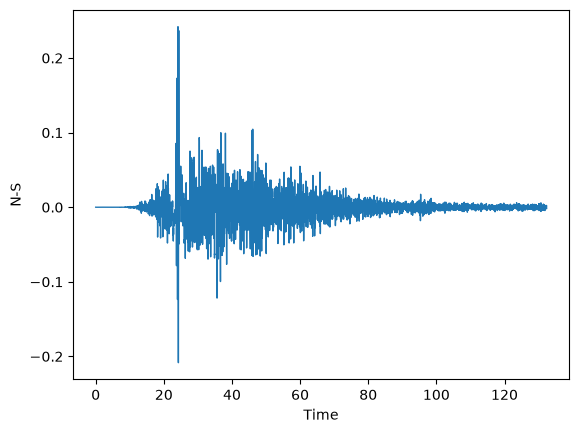

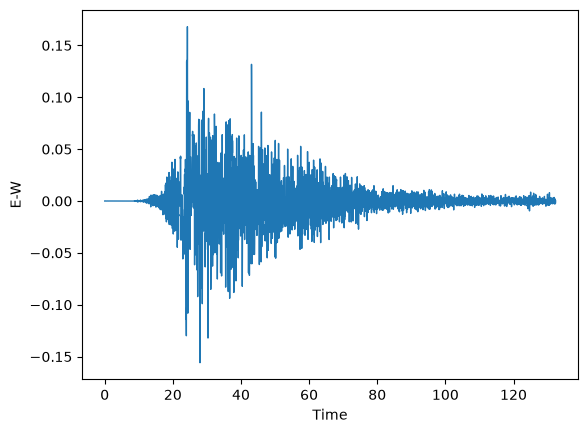

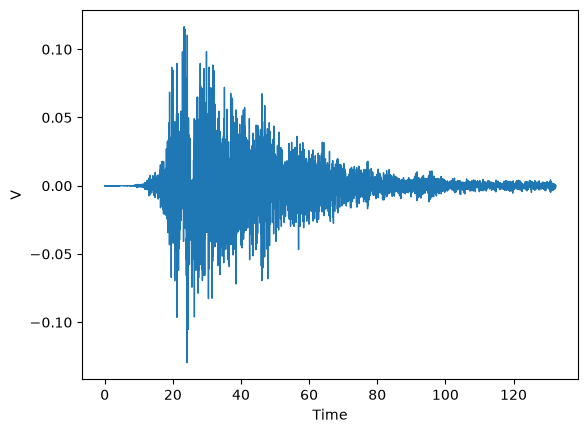

In [4]:
for column in signal.columns[1:]:
    plot_signal(signal["Time"], signal[column], y_label=column)

# Demean signal plots

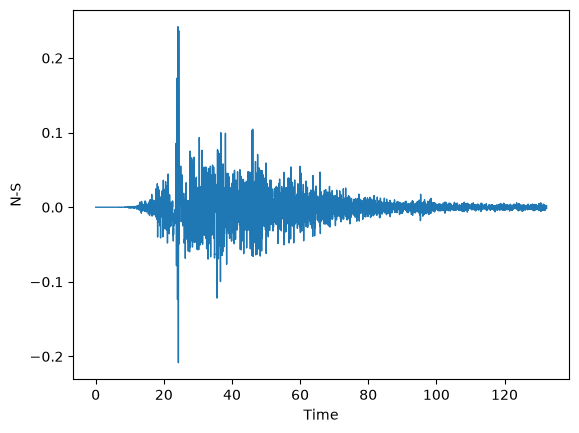

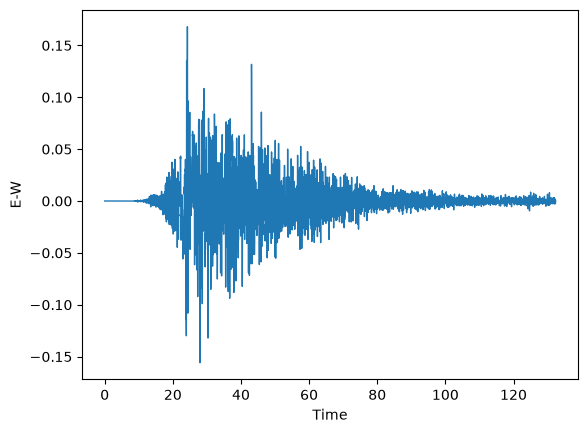

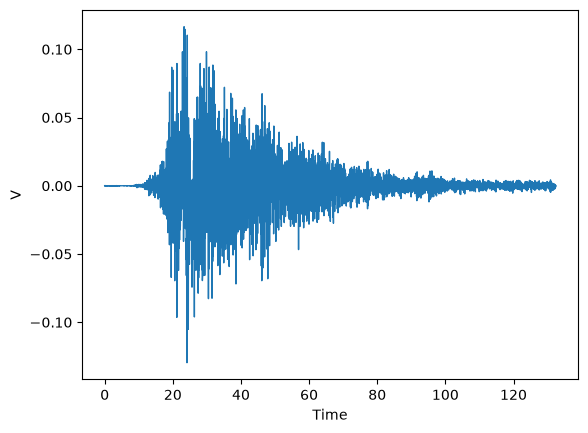

In [5]:
for column in signal.columns[1:]:
    demeaned_signal = signal[column] - np.mean(signal[column])
    plot_signal(signal["Time"], demeaned_signal, y_label=column)

# Fourier Transform

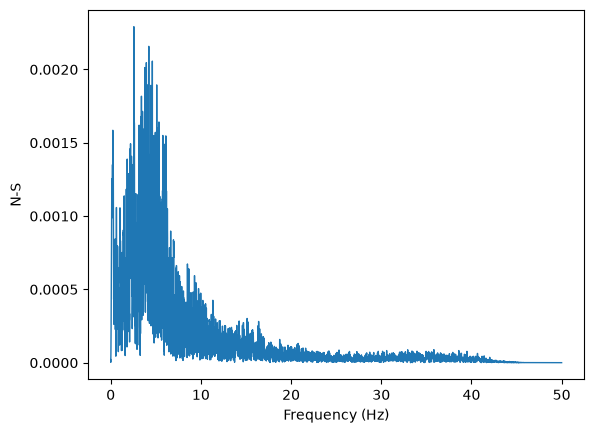

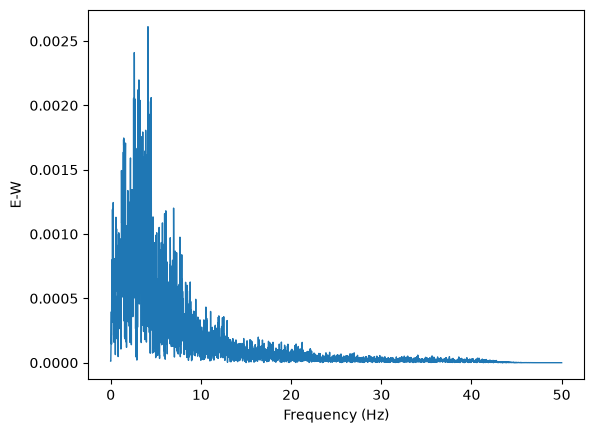

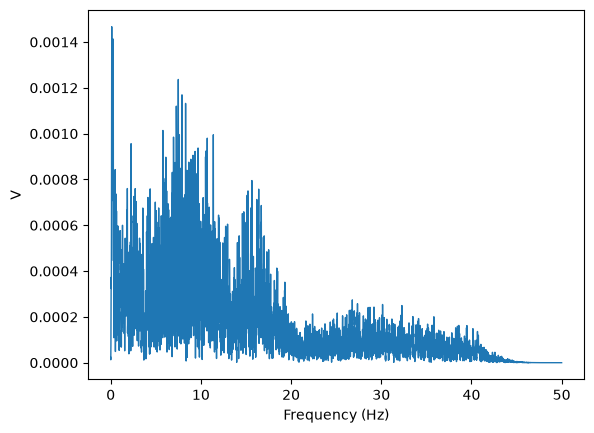

In [6]:
for column in signal.columns[1:]:
    plot_fft(signal[column], 0.01, y_label=column)

# Highpass filter

In [7]:
from scipy.signal import butter, filtfilt

In [8]:
cutoff_freq = 10
sampling_rate = 1 / 0.01
b, a = butter(N=4, Wn=cutoff_freq, btype="high", fs=sampling_rate)

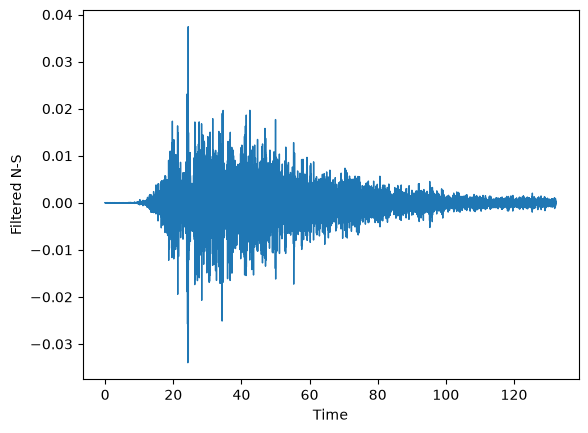

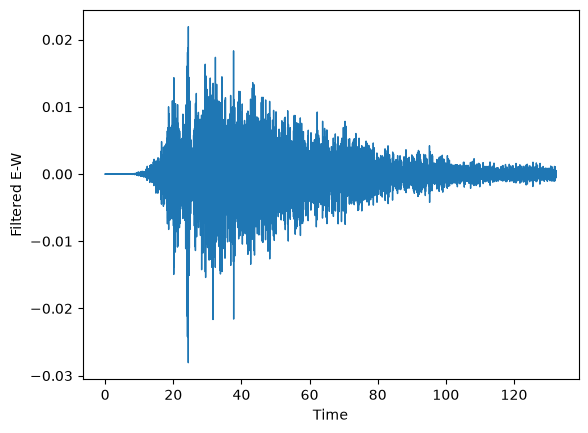

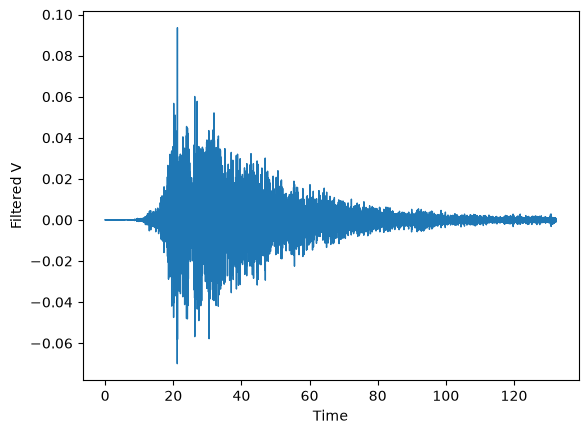

In [9]:
for column in signal.columns[1:]:
    filtered = filtfilt(b, a, signal[column])
    plot_signal(signal["Time"], filtered, y_label=f"Filtered {column}")